In [34]:
import os
import sys
import subprocess

images_dir = "images"
if not os.path.exists(images_dir):
    os.makedirs(images_dir)
    print(f"✅ Created directory: {images_dir}")
else:
    print(f"✅ Directory already exists: {images_dir}")
    

subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly>=6.1.1", "--upgrade"])

print("Plotly upgraded successfully! Please RESTART YOUR KERNEL and try the image export again.")

✅ Directory already exists: images
Plotly upgraded successfully! Please RESTART YOUR KERNEL and try the image export again.


In [35]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

In [36]:
data = pd.read_csv(r'C:\Users\yashp\Downloads\Asus Laptop_Projects\Iphone Analysis\apple_products.csv')
data.head()

,Product Name,Product URL,Brand,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Upc,Star Rating,Ram
0,"APPLE iPhone 8 Plus (Gold, 64 GB)",https://www.flipkart.com/apple-iphone-8-plus-g...,Apple,49900,49900,0,3431,356,MOBEXRGV7EHHTGUH,4.6,2 GB
1,"APPLE iPhone 8 Plus (Space Grey, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVAC6TJT4F,4.6,2 GB
2,"APPLE iPhone 8 Plus (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVGETABXWZ,4.6,2 GB
3,"APPLE iPhone 8 (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-silver...,Apple,77000,77000,0,11202,794,MOBEXRGVMZWUHCBA,4.5,2 GB
4,"APPLE iPhone 8 (Gold, 256 GB)",https://www.flipkart.com/apple-iphone-8-gold-2...,Apple,77000,77000,0,11202,794,MOBEXRGVPK7PFEJZ,4.5,2 GB


## Data Cleaning

In [37]:
data.isnull().sum()

Product Name           0
Product URL            0
Brand                  0
Sale Price             0
Mrp                    0
Discount Percentage    0
Number Of Ratings      0
Number Of Reviews      0
Upc                    0
Star Rating            0
Ram                    0
dtype: int64

In [38]:
# Data set has no missing values

In [39]:
data.describe()

,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Star Rating
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,80073.887097,88058.064516,9.951613,22420.403226,1861.677419,4.575806
std,34310.446132,34728.825597,7.608079,33768.589550,2855.883830,0.059190
min,29999.000000,39900.000000,0.000000,542.000000,42.000000,4.500000
25%,49900.000000,54900.000000,6.000000,740.000000,64.000000,4.500000
50%,75900.000000,79900.000000,10.000000,2101.000000,180.000000,4.600000
75%,117100.000000,120950.000000,14.000000,43470.000000,3331.000000,4.600000
max,140900.000000,149900.000000,29.000000,95909.000000,8161.000000,4.700000


##  Top 10 highest-rated iPhones on Flipkart in India

In [40]:
highest_rated = data.sort_values(by = ["Star Rating"], ascending = False)
highest_rated = highest_rated.head(10)

print(highest_rated['Product Name'])

15                APPLE iPhone 11 Pro Max (Gold, 64 GB)
20      APPLE iPhone 11 Pro Max (Midnight Green, 64 GB)
17          APPLE iPhone 11 Pro Max (Space Grey, 64 GB)
16     APPLE iPhone 11 Pro Max (Midnight Green, 256 GB)
14               APPLE iPhone 11 Pro Max (Gold, 256 GB)
0                     APPLE iPhone 8 Plus (Gold, 64 GB)
12    Apple iPhone XR (Black, 128 GB) (Includes EarP...
11    Apple iPhone XR (Coral, 128 GB) (Includes EarP...
9     Apple iPhone XR ((PRODUCT)RED, 128 GB) (Includ...
1              APPLE iPhone 8 Plus (Space Grey, 256 GB)
Name: Product Name, dtype: object


In [41]:
print(highest_rated)

                                         Product Name  \
15              APPLE iPhone 11 Pro Max (Gold, 64 GB)   
20    APPLE iPhone 11 Pro Max (Midnight Green, 64 GB)   
17        APPLE iPhone 11 Pro Max (Space Grey, 64 GB)   
16   APPLE iPhone 11 Pro Max (Midnight Green, 256 GB)   
14             APPLE iPhone 11 Pro Max (Gold, 256 GB)   
0                   APPLE iPhone 8 Plus (Gold, 64 GB)   
12  Apple iPhone XR (Black, 128 GB) (Includes EarP...   
11  Apple iPhone XR (Coral, 128 GB) (Includes EarP...   
9   Apple iPhone XR ((PRODUCT)RED, 128 GB) (Includ...   
1            APPLE iPhone 8 Plus (Space Grey, 256 GB)   

                                          Product URL  Brand  Sale Price  \
15  https://www.flipkart.com/apple-iphone-11-pro-m...  Apple      117100   
20  https://www.flipkart.com/apple-iphone-11-pro-m...  Apple      117100   
17  https://www.flipkart.com/apple-iphone-11-pro-m...  Apple      117100   
16  https://www.flipkart.com/apple-iphone-11-pro-m...  Apple      13

## No. of ratings of highest-rated iPhones on Flipkart

In [42]:
iphones = highest_rated['Product Name'].value_counts()
label = iphones.index
counts = highest_rated['Number Of Ratings']
figure = px.bar(highest_rated, x = label, y = counts, title = 'No. of ratings of highest-rated iPhones on Flipkart')
figure.update_layout(
                 width = 1200,
                 height = 900 )
figure.show()
# Saving Image
figure.write_image("images/iphone_vs_ratings.png", width=1200, height=900, scale=2)
print("✅ Image successfully saved as PNG!")

✅ Image successfully saved as PNG!


## iPhone with the highest number of reviews on Flipkart

In [43]:
iphones = highest_rated['Product Name'].value_counts()
label = iphones.index
counts = highest_rated['Number Of Reviews']
figure = px.bar(highest_rated, x = label, y = counts, title = 'iPhone with the highest number of reviews')
figure.update_layout(
                 width = 1200,
                 height = 900 )
figure.show()
# Saving Image
figure.write_image("images/iPhone_vs_reviews.png", width=1200, height=900, scale=2)
print("✅ Image successfully saved as PNG!")

✅ Image successfully saved as PNG!


##  Relationship between the sale price of iPhones and the number of ratings on Flipkart

In [44]:
data.head()

,Product Name,Product URL,Brand,Sale Price,Mrp,Discount Percentage,Number Of Ratings,Number Of Reviews,Upc,Star Rating,Ram
0,"APPLE iPhone 8 Plus (Gold, 64 GB)",https://www.flipkart.com/apple-iphone-8-plus-g...,Apple,49900,49900,0,3431,356,MOBEXRGV7EHHTGUH,4.6,2 GB
1,"APPLE iPhone 8 Plus (Space Grey, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVAC6TJT4F,4.6,2 GB
2,"APPLE iPhone 8 Plus (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-plus-s...,Apple,84900,84900,0,3431,356,MOBEXRGVGETABXWZ,4.6,2 GB
3,"APPLE iPhone 8 (Silver, 256 GB)",https://www.flipkart.com/apple-iphone-8-silver...,Apple,77000,77000,0,11202,794,MOBEXRGVMZWUHCBA,4.5,2 GB
4,"APPLE iPhone 8 (Gold, 256 GB)",https://www.flipkart.com/apple-iphone-8-gold-2...,Apple,77000,77000,0,11202,794,MOBEXRGVPK7PFEJZ,4.5,2 GB


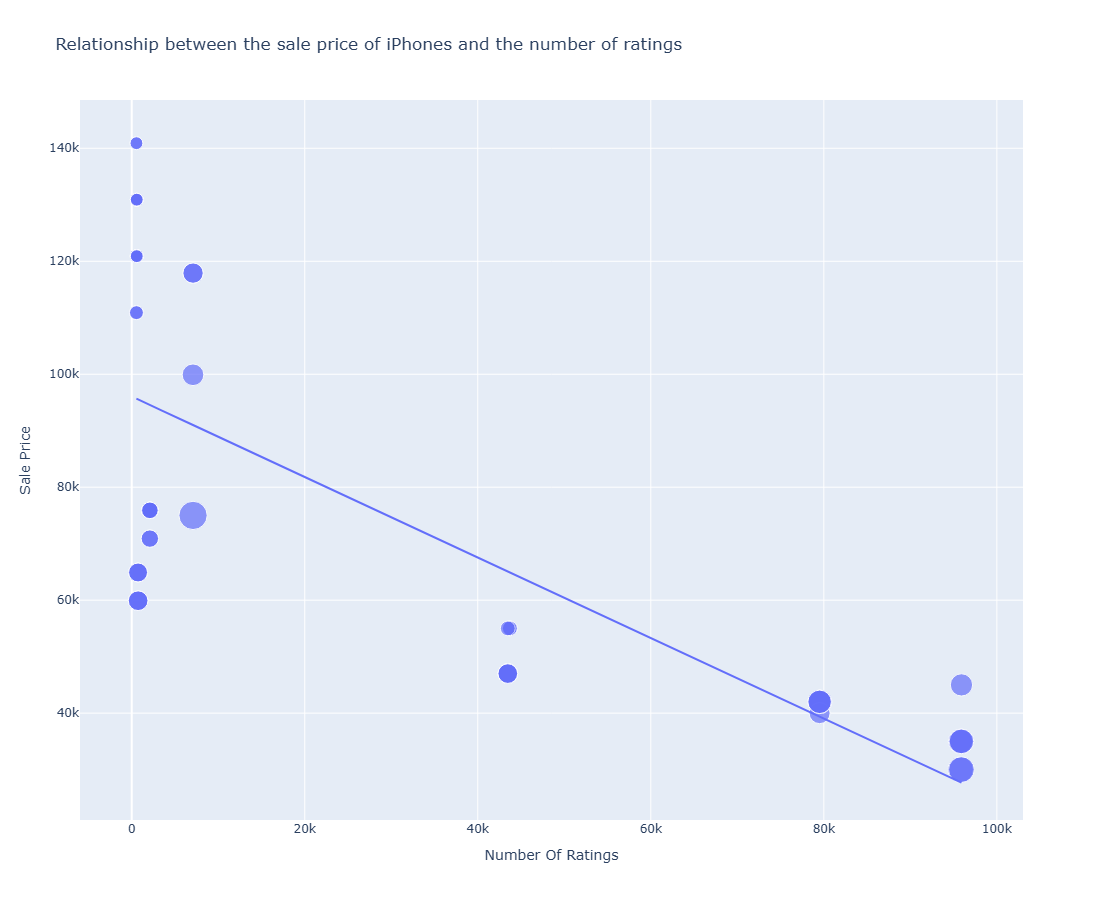

✅ Image successfully saved as PNG!


In [45]:
figure = px.scatter(data_frame = data, x = 'Number Of Ratings', y = 'Sale Price', size = 'Discount Percentage',
                    trendline = 'ols', title = 'Relationship between the sale price of iPhones and the number of ratings')
figure.update_layout(
                 width = 1100,
                 height = 900 )
figure.show()
# Saving Image
figure.write_image("images/relation_bw_saleprice_no_of_ratings.png", width=1100, height=900, scale=2)
print("✅ Image successfully saved as PNG!")

##  Relationship between the discount percentage and the number of ratings of iPhones 

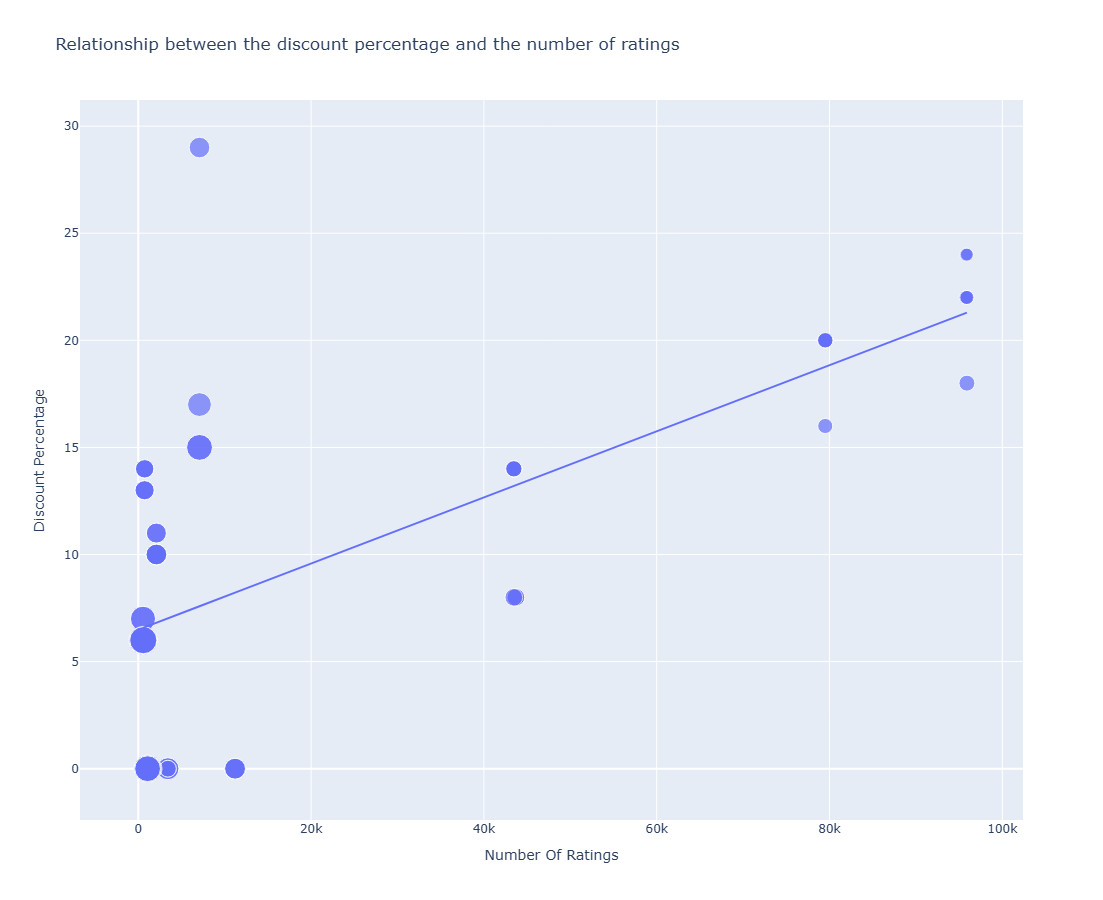

✅ Image successfully saved as PNG!


In [46]:
figure = px.scatter(data_frame = data, x = 'Number Of Ratings', y = 'Discount Percentage', size = 'Sale Price',
                    trendline = 'ols', title = 'Relationship between the discount percentage and the number of ratings')
figure.update_layout(
                 width = 1100,
                 height = 900 )
figure.show()
# Saving Image
figure.write_image("images/relation_bw_discperct_no_of_ratings.png", width=1100, height=900, scale=2)
print("✅ Image successfully saved as PNG!")

## Most expensive and least expensive iphone

In [47]:
most_expensive = data.loc[data['Sale Price'].idxmax()]
least_expensive = data.loc[data['Sale Price'].idxmin()]

#Display results
print("\nMost Expensive iPhone:")
print(most_expensive)

print("\nLeast Expensive iPhone:")
print(least_expensive)


Most Expensive iPhone:
Product Name                        APPLE iPhone 12 Pro (Silver, 512 GB)
Product URL            https://www.flipkart.com/apple-iphone-12-pro-s...
Brand                                                              Apple
Sale Price                                                        140900
Mrp                                                               149900
Discount Percentage                                                    6
Number Of Ratings                                                    542
Number Of Reviews                                                     42
Upc                                                     MOBFWBYZ5UY6ZBVA
Star Rating                                                          4.5
Ram                                                                 4 GB
Name: 24, dtype: object

Least Expensive iPhone:
Product Name                              APPLE iPhone SE (White, 64 GB)
Product URL            https://www.flipkart.com/app